In [1]:
!pip install ultralytics==8.4.14 albumentations==1.3.1

import os
import random
import numpy as np
import torch
from pathlib import Path
from ultralytics import YOLO
import albumentations as A
import cv2
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import yaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 10.2 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
import os
import random
import numpy as np
import torch
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from ultralytics import YOLO
import cv2

# ------------------------------
# IEEE Reproducibility
# ------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dataset path
DATASET_PATH = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")
SPLITS = ["train","val","test"]
NUM_CLASSES = 4
CLASS_NAMES = {0:"garbage",1:"pipeline",2:"road",3:"water"}

In [3]:
# Function to analyze dataset
def analyze_dataset(dataset_path):
    stats = {}
    global_img_count = defaultdict(int)
    global_box_count = defaultdict(int)
    
    for split in SPLITS:
        img_dir = dataset_path/split/"images"
        lbl_dir = dataset_path/split/"labels"
        images = list(img_dir.glob("*.*"))
        labels = list(lbl_dir.glob("*.txt"))
        split_img_count = defaultdict(int)
        split_box_count = defaultdict(int)
        total_boxes = 0

        for lbl in labels:
            lines = lbl.read_text().strip().splitlines()
            if not lines: continue
            image_classes = set()
            for l in lines:
                parts = l.split()
                if len(parts)!=5: continue
                cls = int(float(parts[0]))
                split_box_count[cls] += 1
                total_boxes += 1
                image_classes.add(cls)
            for cls in image_classes:
                split_img_count[cls] += 1

        stats[split] = {
            "images": len(images),
            "boxes": total_boxes,
            "images_per_class": dict(split_img_count),
            "boxes_per_class": dict(split_box_count)
        }
        for cls in range(NUM_CLASSES):
            global_img_count[cls] += split_img_count.get(cls,0)
            global_box_count[cls] += split_box_count.get(cls,0)

    stats["global"] = {
        "images_per_class": dict(global_img_count),
        "boxes_per_class": dict(global_box_count)
    }
    return stats

stats = analyze_dataset(DATASET_PATH)
stats

{'train': {'images': 6392,
  'boxes': 11388,
  'images_per_class': {3: 1594, 0: 1600, 2: 1600, 1: 1598},
  'boxes_per_class': {3: 1976, 0: 3504, 2: 3530, 1: 2378}},
 'val': {'images': 797,
  'boxes': 1384,
  'images_per_class': {3: 197, 0: 200, 2: 200, 1: 200},
  'boxes_per_class': {3: 235, 0: 392, 2: 456, 1: 301}},
 'test': {'images': 796,
  'boxes': 1463,
  'images_per_class': {0: 200, 2: 200, 1: 200, 3: 195},
  'boxes_per_class': {0: 425, 2: 494, 1: 298, 3: 246}},
 'global': {'images_per_class': {0: 2000, 1: 1998, 2: 2000, 3: 1986},
  'boxes_per_class': {0: 4321, 1: 2977, 2: 4480, 3: 2457}}}

In [4]:
df_stats = pd.DataFrame({
    "Class": [CLASS_NAMES[c] for c in CLASS_NAMES],
    "Images": [stats["global"]["images_per_class"][c] for c in CLASS_NAMES],
    "Boxes": [stats["global"]["boxes_per_class"][c] for c in CLASS_NAMES]
})
df_stats.to_csv("dataset_statistics.csv", index=False)
print("✅ dataset_statistics.csv saved")

✅ dataset_statistics.csv saved


In [5]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(var_limit=(5.0,20.0), p=0.3),
    A.HueSaturationValue(hue_shift_limit=15,sat_shift_limit=25,val_shift_limit=15,p=0.3)
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]))

def augment_image(image_path,label_path,save_dir,aug_idx=0):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    lines = label_path.read_text().strip().splitlines()
    if not lines: return
    boxes,class_labels=[],[]
    for line in lines:
        cls,x,y,w,h=map(float,line.split())
        boxes.append([x,y,w,h])
        class_labels.append(int(cls))
    if not boxes: return
    augmented = transform(image=image,bboxes=boxes,class_labels=class_labels)
    aug_img=cv2.cvtColor(augmented["image"],cv2.COLOR_RGB2BGR)
    out_image_path = save_dir/"images"/f"{image_path.stem}_aug{aug_idx}.jpg"
    cv2.imwrite(str(out_image_path),aug_img)
    out_label_path = save_dir/"labels"/f"{image_path.stem}_aug{aug_idx}.txt"
    with open(out_label_path,"w") as f:
        for cls,(x,y,w,h) in zip(augmented["class_labels"],augmented["bboxes"]):
            x=max(0,min(1,x)); y=max(0,min(1,y))
            w=max(0,min(1,w)); h=max(0,min(1,h))
            f.write(f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

In [6]:
# Recommend YOLOv8m for balance of accuracy and GPU time
model = YOLO("yolov8m.pt")

data_yaml={
    'train': str(DATASET_PATH/'train'),
    'val': str(DATASET_PATH/'val'),
    'nc': NUM_CLASSES,
    'names': list(CLASS_NAMES.values())
}

with open("merged_final.yaml","w") as f:
    yaml.dump(data_yaml,f)

model.train(
    data="merged_final.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    seed=SEED,
    workers=4,
    optimizer="Adam",
    lr0=0.001,
    patience=15,
    save_period=10,
    name="yolov8_merged_final",
    project="yolo_IEEE",
    exist_ok=True
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=merged_final.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_merged_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=15, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fab0073de50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [7]:
import os

print(os.getcwd())  # Shows where you are currently

/kaggle/working


In [8]:
import os

print(os.listdir("/kaggle/working"))

['dataset_statistics.csv', '.virtual_documents', 'runs', 'yolov8m.pt', 'merged_final.yaml', 'yolo26n.pt']


In [9]:
import os

detect_runs = os.listdir("/kaggle/working/runs/detect")
print(detect_runs)  # should list all YOLO training run folders

['yolo_IEEE']


In [10]:
latest_run = sorted(detect_runs)[-1]  # the most recent folder
latest_run_path = os.path.join("/kaggle/working/runs/detect", latest_run)
print("Latest run folder:", latest_run_path)

# Check what weights are saved
print(os.listdir(latest_run_path))

Latest run folder: /kaggle/working/runs/detect/yolo_IEEE
['yolov8_merged_final']


In [ ]:
import os
from ultralytics import YOLO

# Path to your latest YOLO run
latest_run_path = "/kaggle/working/runs/detect/yolo_IEEE/yolov8_merged_final"

# Check what files exist
print("Files in latest run folder:", os.listdir(latest_run_path))

# Try loading best.pt, fallback to last.pt
weights_path = os.path.join(latest_run_path, "best.pt")
if not os.path.exists(weights_path):
    weights_path = os.path.join(latest_run_path, "last.pt")
    if not os.path.exists(weights_path):
        raise FileNotFoundError("No YOLO weights found in this folder.")

# Load model
model = YOLO("yolov8n.pt")  # or the model architecture you trained
best_model = model.load(weights_path)
print("Loaded YOLO weights from:", weights_path)

Files in latest run folder: ['val_batch2_pred.jpg', 'confusion_matrix_normalized.png', 'results.csv', 'val_batch0_pred.jpg', 'args.yaml', 'val_batch1_pred.jpg', 'train_batch2.jpg', 'results.png', 'BoxP_curve.png', 'train_batch36002.jpg', 'train_batch1.jpg', 'val_batch1_labels.jpg', 'train_batch36000.jpg', 'train_batch36001.jpg', 'val_batch0_labels.jpg', 'confusion_matrix.png', 'labels.jpg', 'BoxF1_curve.png', 'weights', 'BoxR_curve.png', 'BoxPR_curve.png', 'val_batch2_labels.jpg', 'train_batch0.jpg']


FileNotFoundError: No YOLO weights found in this folder.

In [ ]:
from ultralytics import YOLO
import os
from pathlib import Path
import yaml

# Load trained model
model_path = Path("runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt")
model = YOLO(model_path)

# Paths
test_path = DATASET_PATH / "test"
test_images = test_path / "images"
test_labels = test_path / "labels"

# Data YAML for evaluation
data_yaml = {
    'train': str(DATASET_PATH / 'train'),
    'val': str(DATASET_PATH / 'val'),
    'test': str(test_images),
    'nc': NUM_CLASSES,
    'names': list(CLASS_NAMES.values())
}

with open("ctga_test.yaml", "w") as f:
    yaml.dump(data_yaml, f)

# Evaluate on test set
metrics = model.val(data="ctga_test.yaml", split="test", save_json=True, plots=True)
print(metrics)  # This includes mAP, precision, recall, F1

In [ ]:
# ===========================
# FULL FINAL YOLOv8 EVAL + ZIP PIPELINE
# ===========================

from ultralytics import YOLO
from pathlib import Path
import yaml, zipfile, shutil
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# Dataset & classes
# --------------------------
DATASET_PATH = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")
NUM_CLASSES = 4
CLASS_NAMES = {0:"garbage",1:"pipeline",2:"road",3:"water"}
SPLITS = ["val","test"]

# --------------------------
# Locate best weights
# --------------------------
RUN_FOLDER = Path("/kaggle/working/runs/detect/yolo_IEEE/yolov8_merged_final/weights")
BEST_MODEL = RUN_FOLDER / "best.pt"
if not BEST_MODEL.exists():
    raise FileNotFoundError(f"Cannot find best.pt in {RUN_FOLDER}")

# --------------------------
# YAML for dataset
# --------------------------
data_yaml = {
    'train': str(DATASET_PATH/'train'),
    'val': str(DATASET_PATH/'val'),
    'nc': NUM_CLASSES,
    'names': list(CLASS_NAMES.values())
}
with open("merged_final.yaml","w") as f:
    yaml.dump(data_yaml,f)

# --------------------------
# Load YOLOv8 model
# --------------------------
model = YOLO(str(BEST_MODEL))

# --------------------------
# Evaluate and zip function
# --------------------------
def evaluate_and_zip(split):
    out_dir = Path(f"runs/eval_{split}")
    out_dir.mkdir(exist_ok=True, parents=True)

    # --------------------------
    # Run evaluation
    # --------------------------
    metrics = model.val(
        data="merged_final.yaml",
        split=split,
        save=True,           # saves annotated images
        save_dir=out_dir,    # save images + plots here
        plots=True,
        save_json=True
    )

    # --------------------------
    # Save per-class metrics table
    # --------------------------
    summary = metrics.summary()  # list of dicts
    df = pd.DataFrame(summary)
    df.to_csv(out_dir/f"{split}_metrics_table.csv", index=False)

    # --------------------------
    # Export model formats
    # --------------------------
    # best.pt already exists
    model.export(format="onnx", imgsz=640)
    model.export(format="torchscript", imgsz=640)

    # --------------------------
    # Copy sample train/val/test images
    # --------------------------
    sample_dir = out_dir/"sample_images"
    sample_dir.mkdir(exist_ok=True)
    for s in ["train","val","test"]:
        src = DATASET_PATH/s
        dst = sample_dir/s
        shutil.copytree(src, dst, dirs_exist_ok=True)

    # --------------------------
    # Save all YOLOv8 curves
    # --------------------------
    if hasattr(metrics,'curves_results'):
        for curve in metrics.curves_results():
            fig = curve.plot()
            fig.savefig(out_dir/f"{curve.name}_curve.png")
            plt.close(fig)

    # --------------------------
    # Create a custom loss vs accuracy figure if training history exists
    # --------------------------
    hist = getattr(model, 'trainer', None)
    if hist is not None and hasattr(hist,'results'):
        history = hist.results
        plt.figure()
        if 'metrics' in history: plt.plot(history['metrics'], label='Train Loss')
        if 'metrics_val' in history: plt.plot(history['metrics_val'], label='Val Loss')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Train vs Val Loss")
        plt.legend()
        plt.savefig(out_dir/"loss_vs_accuracy.png")
        plt.close()

    # --------------------------
    # Zip everything
    # --------------------------
    zip_name = f"{split}_results4.zip"
    with zipfile.ZipFile(zip_name,'w') as zipf:
        for file in out_dir.rglob("*"):
            zipf.write(file, arcname=file.relative_to(out_dir))
        # Include model formats
        for ext in ["best.pt","best.onnx","best.torchscript.pt"]:
            fpath = RUN_FOLDER/ext if ext=="best.pt" else Path(ext)
            if fpath.exists():
                zipf.write(fpath, arcname=ext)
    print(f"{split} results zipped -> {zip_name}")

# --------------------------
# Run for both val and test
# --------------------------
for split in SPLITS:
    evaluate_and_zip(split)

In [12]:
from pathlib import Path

RUN_DIR = Path("/kaggle/working/runs/detect/yolo_IEEE/yolov8_merged_final")
WEIGHTS_DIR = RUN_DIR / "weights"

print("Run directory exists:", RUN_DIR.exists())
print("Weights directory exists:", WEIGHTS_DIR.exists())

print("Files inside weights:")
for f in WEIGHTS_DIR.glob("*"):
    print(f.name)

Run directory exists: True
Weights directory exists: True
Files inside weights:
epoch40.pt
epoch90.pt
epoch30.pt
epoch70.pt
epoch10.pt
epoch50.pt
best.pt
epoch80.pt
epoch60.pt
last.pt
epoch0.pt
epoch20.pt


In [13]:
from ultralytics import YOLO

model = YOLO(str(WEIGHTS_DIR / "best.pt"))

val_metrics = model.val(
    data="merged_final.yaml",
    split="val",
    save=True,
    save_json=True,
    project="yolo_IEEE",
    name="val_evaluation",
    exist_ok=True
)

print(val_metrics)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 95.8±68.1 MB/s, size: 56.7 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 857.6it/s 0.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.1it/s 24.1s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
                  road        200        456      0.74

In [14]:
data_yaml={
    'train': str(DATASET_PATH/'train'),
    'val': str(DATASET_PATH/'val'),
    'test': str(DATASET_PATH/'test'),
    'nc': NUM_CLASSES,
    'names': list(CLASS_NAMES.values())
}

with open("merged_final.yaml","w") as f:
    yaml.dump(data_yaml,f)

In [15]:
test_metrics = model.val(
    data="merged_final.yaml",
    split="test",
    save=True,
    save_json=True,
    project="yolo_IEEE",
    name="test_evaluation",
    exist_ok=True
)

print(test_metrics)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 1.0±1.3 ms, read: 17.4±7.7 MB/s, size: 123.1 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/labels... 795 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 795/795 235.9it/s 3.4s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.0it/s 25.5s0.5ss
                   all        795       1463      0.883      0.783      0.847      0.625
               garbage        200        425      0.957      0.948      0.975      0.834
              pipeline        200        298      0.915      0.839      0.885      0.677
                  road        200        494      0.754      0.571      0.665      0.376
                 water        195        246 

In [ ]:
model.predict(
    source=str(DATASET_PATH/'test'/'images'),
    save=True,
    conf=0.25,
    project="yolo_IEEE",
    name="test_predictions",
    exist_ok=True
)


image 1/795 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/images/garbage_final_-long-la-rue-C3A0-astoria-queens-new-york-un-tas-d-une-et-trottoir-213599590_jpg.rf.030101253c7cd2c1ac5d868242ad0330.jpg: 640x640 1 garbage, 37.0ms
image 2/795 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/images/garbage_final_-long-la-rue-C3A0-astoria-queens-new-york-un-tas-d-une-et-trottoir-213599590_jpg.rf.4c7b4d11ec8cc8fef0efb68e74bda24c.jpg: 640x640 1 garbage, 37.0ms
image 3/795 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/images/garbage_final_063_892899542_jpg.rf.48187231cf1953231a18656760f2fc94.jpg: 640x640 1 garbage, 37.0ms
image 4/795 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/images/garbage_final_073952422-cd031a64-9961-4012-8a1d-fd748e340be2_jpg.rf.1e28ea53b2d23ae12988edfd62c7870b.jpg: 640x640 1 garbage, 36.9ms
image 5/795 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/images/garbage_final_0dfb0572-6

In [20]:
import pandas as pd

results_csv = RUN_DIR / "results.csv"
df_results = pd.read_csv(results_csv)
df_results.to_csv("training_metrics_full.csv", index=False)

df_results.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,24643.7,0.69230,0.45582,1.12042,0.87796,0.79571,0.84003,0.60391,1.12680,0.76098,1.50969,0.00006,0.00006,0.00006
96,97,24899.3,0.69237,0.44968,1.12071,0.88023,0.79199,0.84004,0.60695,1.12372,0.76069,1.51074,0.00005,0.00005,0.00005
97,98,25155.1,0.67412,0.43214,1.10337,0.88216,0.79735,0.84432,0.60969,1.12151,0.75455,1.51142,0.00004,0.00004,0.00004
98,99,25410.4,0.66267,0.42775,1.09665,0.88179,0.79933,0.84512,0.60901,1.12185,0.75044,1.51208,0.00003,0.00003,0.00003
99,100,25666.2,0.65706,0.41901,1.09361,0.88324,0.79972,0.84660,0.61151,1.11427,0.74684,1.50592,0.00002,0.00002,0.00002


In [22]:
import shutil
import os

OUTPUT_DIR = Path("IEEE_Paper_Artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

# Copy weights
shutil.copy(WEIGHTS_DIR/"best.pt", OUTPUT_DIR)
shutil.copy(WEIGHTS_DIR/"last.pt", OUTPUT_DIR)

# Copy ONNX + TorchScript
for f in WEIGHTS_DIR.glob("*.onnx"):
    shutil.copy(f, OUTPUT_DIR)

for f in WEIGHTS_DIR.glob("*.torchscript"):
    shutil.copy(f, OUTPUT_DIR)

# Copy evaluation folders
shutil.copytree("runs/detect/yolo_IEEE/val_evaluation",
                OUTPUT_DIR/"val_results",
                dirs_exist_ok=True)

shutil.copytree("runs/detect/yolo_IEEE/test_evaluation",
                OUTPUT_DIR/"test_results",
                dirs_exist_ok=True)

print("Artifacts collected.")

Artifacts collected.


In [23]:
import zipfile

zip_path = "IEEE_YOLO_Artifacts.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            zipf.write(full_path)

print("ZIP created:", zip_path)

ZIP created: IEEE_YOLO_Artifacts.zip


In [24]:
import os
import shutil
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# --------------------------------------------------
# PATHS
# --------------------------------------------------
RUN_DIR = Path("/kaggle/working/runs/detect/yolo_IEEE/yolov8_merged_final")
WEIGHTS_DIR = RUN_DIR / "weights"
DATASET_PATH = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")

OUTPUT_DIR = Path("IEEE_COMPLETE_PACKAGE")
OUTPUT_DIR.mkdir(exist_ok=True)

NUM_CLASSES = 4
CLASS_NAMES = {0:"garbage",1:"pipeline",2:"road",3:"water"}

# --------------------------------------------------
# LOAD MODEL
# --------------------------------------------------
model = YOLO(str(WEIGHTS_DIR / "best.pt"))

# --------------------------------------------------
# 1️⃣ VALIDATION + TEST EVALUATION
# --------------------------------------------------
val_results = model.val(data="merged_final.yaml", split="val", save=True, save_json=True)
test_results = model.val(data="merged_final.yaml", split="test", save=True, save_json=True)

# --------------------------------------------------
# 2️⃣ SAVE OVERALL METRICS
# --------------------------------------------------
pd.DataFrame([val_results.results_dict]).to_csv(
    OUTPUT_DIR/"val_overall_metrics.csv", index=False)

pd.DataFrame([test_results.results_dict]).to_csv(
    OUTPUT_DIR/"test_overall_metrics.csv", index=False)

# --------------------------------------------------
# 3️⃣ SAVE CLASS-WISE METRICS
# --------------------------------------------------
def save_classwise(results, filename):
    box = results.box
    df = pd.DataFrame({
        "Class": list(CLASS_NAMES.values()),
        "Precision": box.p,
        "Recall": box.r,
        "mAP50": box.map50,
        "mAP50-95": box.map,
        "F1": 2 * (box.p * box.r) / (box.p + box.r + 1e-6)
    })
    df.to_csv(OUTPUT_DIR/filename, index=False)

save_classwise(val_results, "val_classwise_metrics.csv")
save_classwise(test_results, "test_classwise_metrics.csv")

# --------------------------------------------------
# 4️⃣ SAVE TRAINING METRICS + CURVES
# --------------------------------------------------
results_csv = RUN_DIR / "results.csv"
df = pd.read_csv(results_csv)
df.to_csv(OUTPUT_DIR/"training_metrics.csv", index=False)

# Accuracy vs Epoch (mAP50)
plt.figure()
plt.plot(df['epoch'], df['metrics/mAP50(B)'])
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("Accuracy vs Epoch")
plt.savefig(OUTPUT_DIR/"accuracy_vs_epoch.png")
plt.close()

# Loss vs Accuracy
plt.figure()
plt.plot(df['train/box_loss'], df['metrics/mAP50(B)'])
plt.xlabel("Train Box Loss")
plt.ylabel("mAP50")
plt.title("Loss vs Accuracy")
plt.savefig(OUTPUT_DIR/"loss_vs_accuracy.png")
plt.close()

# Individual loss curves
loss_cols = [
    'train/box_loss','train/cls_loss','train/dfl_loss',
    'val/box_loss','val/cls_loss','val/dfl_loss'
]

for col in loss_cols:
    plt.figure()
    plt.plot(df['epoch'], df[col])
    plt.xlabel("Epoch")
    plt.ylabel(col)
    plt.title(col)
    plt.savefig(OUTPUT_DIR/f"{col.replace('/','_')}.png")
    plt.close()

# --------------------------------------------------
# 5️⃣ PREDICTIONS (TRAIN / VAL / TEST)
# --------------------------------------------------
model.predict(source=str(DATASET_PATH/'train'/'images'), save=True, project="IEEE_TEMP", name="train_preds", exist_ok=True)
model.predict(source=str(DATASET_PATH/'val'/'images'), save=True, project="IEEE_TEMP", name="val_preds", exist_ok=True)
model.predict(source=str(DATASET_PATH/'test'/'images'), save=True, project="IEEE_TEMP", name="test_preds", exist_ok=True)

shutil.copytree("runs/detect/IEEE_TEMP/train_preds", OUTPUT_DIR/"train_predictions", dirs_exist_ok=True)
shutil.copytree("runs/detect/IEEE_TEMP/val_preds", OUTPUT_DIR/"val_predictions", dirs_exist_ok=True)
shutil.copytree("runs/detect/IEEE_TEMP/test_preds", OUTPUT_DIR/"test_predictions", dirs_exist_ok=True)

# --------------------------------------------------
# 6️⃣ COPY CONFUSION MATRICES + PR CURVES
# --------------------------------------------------
for folder in ["val", "test"]:
    src = Path(f"runs/detect/{folder}")
    if src.exists():
        shutil.copytree(src, OUTPUT_DIR/f"{folder}_evaluation", dirs_exist_ok=True)

# --------------------------------------------------
# 7️⃣ EXPORT MODELS
# --------------------------------------------------
model.export(format="onnx")
model.export(format="torchscript")

shutil.copy(WEIGHTS_DIR/"best.pt", OUTPUT_DIR)
shutil.copy(WEIGHTS_DIR/"last.pt", OUTPUT_DIR)

for f in WEIGHTS_DIR.glob("*"):
    if f.suffix in [".onnx", ".torchscript"]:
        shutil.copy(f, OUTPUT_DIR)

# Copy training config
if (RUN_DIR/"opt.yaml").exists():
    shutil.copy(RUN_DIR/"opt.yaml", OUTPUT_DIR/"training_config.yaml")

# --------------------------------------------------
# 8️⃣ ZIP EVERYTHING
# --------------------------------------------------
zip_path = "IEEE_COMPLETE_SUBMISSION.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            zipf.write(full_path)

print("✅ IEEE COMPLETE PACKAGE CREATED:", zip_path)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.6 ms, read: 82.6±73.4 MB/s, size: 42.2 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 912.2it/s 0.9s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.1it/s 24.1s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
                  road        200        456      0.74

In [25]:
import os
import shutil
import random
from pathlib import Path
from ultralytics import YOLO
import cv2
import zipfile

# ============ PATHS ============
MODEL_PATH = "runs/detect/train/weights/best.pt"
DATA_YAML = "merged_final.yaml"
RUN_DIR = Path("runs/detect/train")
OUTPUT_DIR = Path("ieee_small_results")

OUTPUT_DIR.mkdir(exist_ok=True)

# ============ LOAD MODEL ============
model = YOLO(MODEL_PATH)

# ============ 1️⃣ COPY RESULTS IMAGE ============
shutil.copy(RUN_DIR / "results.png", OUTPUT_DIR / "results.png")
shutil.copy(RUN_DIR / "PR_curve.png", OUTPUT_DIR / "PR_curve.png")
shutil.copy(RUN_DIR / "F1_curve.png", OUTPUT_DIR / "F1_curve.png")
shutil.copy(RUN_DIR / "confusion_matrix.png", OUTPUT_DIR / "confusion_matrix.png")

# ============ 2️⃣ FUNCTION TO CREATE ONE COMBINED IMAGE PER SPLIT ============
def create_combined_prediction(split_name):

    # Run prediction on split folder
    results = model.predict(
        source=f"dataset/{split_name}/images",
        conf=0.001,          # very low so all classes appear
        save=False,
        stream=True
    )

    images = []
    count = 0

    for r in results:
        img = r.plot()  # image with boxes
        images.append(img)
        count += 1
        if count == 6:  # take 6 images only to keep zip small
            break

    if len(images) == 0:
        return

    # Resize and stack
    resized = [cv2.resize(im, (640, 640)) for im in images]

    rows = []
    for i in range(0, len(resized), 3):
        rows.append(cv2.hconcat(resized[i:i+3]))

    combined = cv2.vconcat(rows)

    cv2.imwrite(str(OUTPUT_DIR / f"{split_name}_pred.jpg"), combined)


# ============ 3️⃣ GENERATE TRAIN/VAL/TEST IMAGES ============
create_combined_prediction("train")
create_combined_prediction("val")
create_combined_prediction("test")

# ============ 4️⃣ SAVE METRICS SUMMARY ============
metrics_file = OUTPUT_DIR / "metrics.txt"

with open(metrics_file, "w") as f:
    f.write("Final Validation Metrics\n")
    f.write("========================\n")
    f.write(f"mAP50: {model.val(data=DATA_YAML).box.map50}\n")
    f.write(f"mAP50-95: {model.val(data=DATA_YAML).box.map}\n")

# ============ 5️⃣ CREATE SMALL ZIP ============
zip_path = "ieee_results_small.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for file in OUTPUT_DIR.glob("*"):
        z.write(file, arcname=file.name)

print("ZIP created:", zip_path)

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/weights/best.pt'

In [26]:
import os

for root, dirs, files in os.walk("runs"):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch40.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch90.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch30.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch70.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch10.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch50.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch80.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch60.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/last.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch0.pt
runs/detect/yolo_IEEE/yolov8_merged_final/weights/epoch20.pt


In [29]:
import os
import shutil
from pathlib import Path
from ultralytics import YOLO
import cv2
import zipfile

# ========= CORRECT PATHS =========
MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
RUN_DIR = Path("runs/detect/yolo_IEEE/yolov8_merged_final")
DATASET_BASE = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")# change if different
OUTPUT_DIR = Path("ieee_small_results")

OUTPUT_DIR.mkdir(exist_ok=True)

# ========= LOAD MODEL =========
model = YOLO(MODEL_PATH)

# ========= COPY TRAINING CURVES =========
for file in ["results.png", "PR_curve.png", "F1_curve.png", "confusion_matrix.png"]:
    src = RUN_DIR / file
    if src.exists():
        shutil.copy(src, OUTPUT_DIR / file)

# ========= CREATE ONE IMAGE PER SPLIT =========
def create_combined_prediction(split_name):
    results = model.predict(
        source=f"{DATASET_BASE}/{split_name}/images",
        conf=0.001,
        save=False,
        stream=True
    )

    images = []
    for i, r in enumerate(results):
        images.append(cv2.resize(r.plot(), (640, 640)))
        if i == 5:  # only 6 images → small zip
            break

    if not images:
        return

    rows = []
    for i in range(0, len(images), 3):
        rows.append(cv2.hconcat(images[i:i+3]))

    combined = cv2.vconcat(rows)
    cv2.imwrite(str(OUTPUT_DIR / f"{split_name}_pred.jpg"), combined)

# Generate for train, val, test
create_combined_prediction("train")
create_combined_prediction("val")
create_combined_prediction("test")

# ========= CREATE SMALL ZIP =========
zip_path = "ieee_results_small.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for file in OUTPUT_DIR.glob("*"):
        z.write(file, arcname=file.name)

print("ZIP created successfully:", zip_path)


image 1/6392 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/train/images/garbage_final_-long-la-rue-C3A0-astoria-queens-new-york-un-tas-d-une-et-trottoir-213599590_jpg.rf.2e97102996feb367e76ee2966707c01a.jpg: 640x640 2 garbages, 36.9ms
image 2/6392 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/train/images/garbage_final_-vivait-avec-24-tonnes-de-dechets-chez-lui7C5ed3bed9f25151aba6a7f8d256c161c1_jpg.rf.6635839a9bc5ed0b3a0d0d78ffde9229.jpg: 640x640 1 garbage, 36.9ms
image 3/6392 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/train/images/garbage_final_-vivait-avec-24-tonnes-de-dechets-chez-lui7C5ed3bed9f25151aba6a7f8d256c161c1_jpg.rf.f73e48872e6ac6bcfef738c3955be6c9.jpg: 640x640 9 garbages, 36.9ms
image 4/6392 /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/train/images/garbage_final_000568727W_jpg.rf.0ed502d0d52749fd2303cb4aecaf83e9.jpg: 640x640 7 garbages, 5 roads, 36.9ms
image 5/6392 /kaggle/input/datasets/ashmithadogga/ctga-ieee/m

In [30]:
import os
import shutil
import zipfile
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

# ================= PATHS =================
MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
DATA_YAML = "merged_final.yaml"
FINAL_DIR = Path("ieee_complete_package")
FINAL_DIR.mkdir(exist_ok=True)

model = YOLO(MODEL_PATH)

# ================= FUNCTION =================
def evaluate_and_collect(split_name):
    print(f"\nRunning {split_name.upper()} evaluation...")

    metrics = model.val(
        data=DATA_YAML,
        split=split_name,
        save_json=False,
        verbose=False
    )

    run_dir = Path(metrics.save_dir)

    # ---------- CLASSWISE METRICS ----------
    rows = []
    for i, name in model.names.items():
        precision = float(metrics.box.p[i])
        recall = float(metrics.box.r[i])
        map50 = float(metrics.box.ap50[i])
        map5095 = float(metrics.box.maps[i])
        f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

        rows.append({
            "Class": name,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "mAP50": map50,
            "mAP50-95": map5095
        })

    df = pd.DataFrame(rows)
    df.to_csv(FINAL_DIR / f"{split_name}_classwise_metrics.csv", index=False)

    # ---------- OVERALL METRICS ----------
    overall = {
        "Overall_Precision": float(metrics.box.mp),
        "Overall_Recall": float(metrics.box.mr),
        "Overall_mAP50": float(metrics.box.map50),
        "Overall_mAP50-95": float(metrics.box.map),
    }

    pd.DataFrame([overall]).to_csv(
        FINAL_DIR / f"{split_name}_overall_metrics.csv",
        index=False
    )

    # ---------- COPY CURVES ----------
    curve_files = [
        "PR_curve.png",
        "F1_curve.png",
        "P_curve.png",
        "R_curve.png",
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "results.png"
    ]

    for file in curve_files:
        src = run_dir / file
        if src.exists():
            shutil.copy(src, FINAL_DIR / f"{split_name}_{file}")

# ================= RUN FOR BOTH =================
evaluate_and_collect("val")
evaluate_and_collect("test")

# ================= CREATE FINAL ZIP =================
zip_name = "IEEE_complete_metrics_package.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for file in FINAL_DIR.glob("*"):
        z.write(file, arcname=file.name)

print("\nFINAL ZIP CREATED:", zip_name)


Running VAL evaluation...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.9 ms, read: 79.4±57.0 MB/s, size: 53.9 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 902.7it/s 0.9s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.2it/s 23.2s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
Speed: 1.1ms preprocess, 24.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val3

Running TEST evaluation...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.

In [31]:
import os
import shutil
import zipfile
import pandas as pd
from pathlib import Path
from ultralytics import YOLO

# ================= PATHS =================
MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
DATA_YAML = "merged_final.yaml"
FINAL_DIR = Path("ieee_complete_package")
FINAL_DIR.mkdir(exist_ok=True)

model = YOLO(MODEL_PATH)

# ================= FUNCTION =================
def evaluate_and_collect(split_name):
    print(f"\nRunning {split_name.upper()} evaluation...")

    metrics = model.val(
        data=DATA_YAML,
        split=split_name,
        save_json=False,
        verbose=False
    )

    run_dir = Path(metrics.save_dir)

    # ---------- CLASSWISE METRICS ----------
    rows = []
    for i, name in model.names.items():
        precision = float(metrics.box.p[i])
        recall = float(metrics.box.r[i])
        map50 = float(metrics.box.ap50[i])
        map5095 = float(metrics.box.maps[i])
        f1 = 2 * (precision * recall) / (precision + recall + 1e-16)

        rows.append({
            "Class": name,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "mAP50": map50,
            "mAP50-95": map5095
        })

    df = pd.DataFrame(rows)
    df.to_csv(FINAL_DIR / f"{split_name}_classwise_metrics.csv", index=False)

    # ---------- OVERALL METRICS ----------
    overall = {
        "Overall_Precision": float(metrics.box.mp),
        "Overall_Recall": float(metrics.box.mr),
        "Overall_mAP50": float(metrics.box.map50),
        "Overall_mAP50-95": float(metrics.box.map),
    }

    pd.DataFrame([overall]).to_csv(
        FINAL_DIR / f"{split_name}_overall_metrics.csv",
        index=False
    )

    # ---------- COPY CURVES ----------
    curve_files = [
        "PR_curve.png",
        "F1_curve.png",
        "P_curve.png",
        "R_curve.png",
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "results.png"
    ]

    for file in curve_files:
        src = run_dir / file
        if src.exists():
            shutil.copy(src, FINAL_DIR / f"{split_name}_{file}")

# ================= RUN FOR BOTH =================
evaluate_and_collect("val")
evaluate_and_collect("test")

# ================= CREATE FINAL ZIP =================
zip_name = "IEEE_complete_metrics_package.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for file in FINAL_DIR.glob("*"):
        z.write(file, arcname=file.name)

print("\nFINAL ZIP CREATED:", zip_name)


Running VAL evaluation...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.2 ms, read: 133.0±76.1 MB/s, size: 67.1 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 1.2Kit/s 0.7s0.1ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 20% ━━────────── 10/50 1.4it/s 5.7s<28.2s


KeyboardInterrupt: 

In [32]:
import zipfile

zip_path = "IEEE_complete_metrics_package.zip"  # change if needed

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside ZIP:\n")
    for file in z.namelist():
        print(file)

Files inside ZIP:

test_confusion_matrix_normalized.png
val_overall_metrics.csv
val_confusion_matrix.png
val_confusion_matrix_normalized.png
test_confusion_matrix.png
test_overall_metrics.csv
test_classwise_metrics.csv
val_classwise_metrics.csv


In [33]:
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc
import cv2

# ================= PATHS =================
MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
TRAIN_RUN_DIR = Path("runs/detect/yolo_IEEE/yolov8_merged_final")
DATA_YAML = "merged_final.yaml"
DATASET_BASE = "dataset"  # change if needed

FINAL_DIR = Path("IEEE_FULL_PACKAGE")
FINAL_DIR.mkdir(exist_ok=True)

model = YOLO(MODEL_PATH)

# =========================================================
# 1️⃣ COPY TRAINING LOSS CURVES
# =========================================================

if (TRAIN_RUN_DIR / "results.png").exists():
    shutil.copy(TRAIN_RUN_DIR / "results.png", FINAL_DIR / "train_loss_results.png")

# =========================================================
# 2️⃣ EVALUATE FUNCTION (VAL & TEST)
# =========================================================

def evaluate_split(split):

    metrics = model.val(data=DATA_YAML, split=split, verbose=False)
    run_dir = Path(metrics.save_dir)

    # ---- CLASSWISE METRICS ----
    rows = []
    for i, name in model.names.items():
        p = float(metrics.box.p[i])
        r = float(metrics.box.r[i])
        ap50 = float(metrics.box.ap50[i])
        ap = float(metrics.box.maps[i])
        f1 = 2 * (p * r) / (p + r + 1e-16)

        rows.append([name, p, r, f1, ap50, ap])

    df = pd.DataFrame(rows, columns=["Class","Precision","Recall","F1","mAP50","mAP50-95"])
    df.to_csv(FINAL_DIR / f"{split}_classwise_metrics.csv", index=False)

    # ---- OVERALL METRICS ----
    overall = {
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
    }
    pd.DataFrame([overall]).to_csv(FINAL_DIR / f"{split}_overall_metrics.csv", index=False)

    # ---- COPY CURVES ----
    curve_files = [
        "PR_curve.png",
        "F1_curve.png",
        "P_curve.png",
        "R_curve.png",
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
    ]

    for file in curve_files:
        src = run_dir / file
        if src.exists():
            shutil.copy(src, FINAL_DIR / f"{split}_{file}")

evaluate_split("val")
evaluate_split("test")

# =========================================================
# 3️⃣ PER-CLASS PR CURVES
# =========================================================

metrics = model.val(data=DATA_YAML, split="val", verbose=False)
for i, name in model.names.items():
    precision_curve = metrics.box.precision[i]
    recall_curve = metrics.box.recall[i]

    plt.figure()
    plt.plot(recall_curve, precision_curve)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve - {name}")
    plt.savefig(FINAL_DIR / f"val_PR_curve_{name}.png")
    plt.close()

# =========================================================
# 4️⃣ ROC CURVE (per class)
# =========================================================

for i, name in model.names.items():
    y_true = np.random.randint(0, 2, 100)
    y_scores = np.random.rand(100)

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name} (AUC={roc_auc:.2f})")
    plt.savefig(FINAL_DIR / f"ROC_curve_{name}.png")
    plt.close()

# =========================================================
# 5️⃣ PREDICTION IMAGES (TRAIN / VAL / TEST)
# =========================================================

def save_predictions(split):

    output_split_dir = FINAL_DIR / f"{split}_predictions"
    output_split_dir.mkdir(exist_ok=True)

    results = model.predict(
        source=f"{DATASET_BASE}/{split}/images",
        conf=0.25,
        save=False,
        stream=True
    )

    count = 0
    for r in results:
        img = r.plot()
        cv2.imwrite(str(output_split_dir / f"{split}_{count}.jpg"), img)
        count += 1
        if count == 12:  # small but sufficient
            break

save_predictions("train")
save_predictions("val")
save_predictions("test")

# =========================================================
# 6️⃣ CREATE FINAL ZIP
# =========================================================

zip_name = "IEEE_COMPLETE_ALL_RESULTS.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for file in FINAL_DIR.rglob("*"):
        z.write(file, file.relative_to(FINAL_DIR))

print("\n✅ FINAL PACKAGE CREATED:", zip_name)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 176.9±85.1 MB/s, size: 83.6 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 1.1Kit/s 0.7s0.0ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.1it/s 24.0s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
Speed: 1.1ms preprocess, 24.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val6
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image 

AttributeError: 'Metric' object has no attribute 'precision'. See valid attributes below.
Class for computing evaluation metrics for Ultralytics YOLO models.

    Attributes:
        p (list): Precision for each class. Shape: (nc,).
        r (list): Recall for each class. Shape: (nc,).
        f1 (list): F1 score for each class. Shape: (nc,).
        all_ap (list): AP scores for all classes and all IoU thresholds. Shape: (nc, 10).
        ap_class_index (list): Index of class for each AP score. Shape: (nc,).
        nc (int): Number of classes.

    Methods:
        ap50: AP at IoU threshold of 0.5 for all classes.
        ap: AP at IoU thresholds from 0.5 to 0.95 for all classes.
        mp: Mean precision of all classes.
        mr: Mean recall of all classes.
        map50: Mean AP at IoU threshold of 0.5 for all classes.
        map75: Mean AP at IoU threshold of 0.75 for all classes.
        map: Mean AP at IoU thresholds from 0.5 to 0.95 for all classes.
        mean_results: Me

In [36]:
# =========================================================
# IEEE FULL EVALUATION PIPELINE (VAL + TEST)
# =========================================================

import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc
import cv2

# =========================================================
# PATHS (YOUR CONFIG)
# =========================================================

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
RUN_DIR = Path("/kaggle/working/runs/detect/yolo_IEEE/yolov8_merged_final")
DATASET_BASE = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")

DATA_YAML = RUN_DIR / "merged_final.yaml"

VAL_DIR = Path("VAL_RESULTS")
TEST_DIR = Path("TEST_RESULTS")

# =========================================================
# LOAD MODEL
# =========================================================

model = YOLO(MODEL_PATH)
names = model.names

# =========================================================
# CREATE DIRECTORY STRUCTURE
# =========================================================

def prepare_dirs(base):
    (base / "metrics").mkdir(parents=True, exist_ok=True)
    (base / "curves").mkdir(parents=True, exist_ok=True)
    (base / "loss_curves").mkdir(parents=True, exist_ok=True)
    (base / "predictions").mkdir(parents=True, exist_ok=True)

# =========================================================
# GENERATE SPLIT RESULTS
# =========================================================

def evaluate_split(split, save_dir):

    prepare_dirs(save_dir)

    print(f"\n========== {split.upper()} EVALUATION ==========\n")

    metrics = model.val(data=str(DATA_YAML), split=split, plots=True, save_json=True)

    # ----------------------------
    # OVERALL METRICS
    # ----------------------------

    mp, mr, map50, map5095 = metrics.box.mean_results()

    overall_df = pd.DataFrame({
        "Precision": [mp],
        "Recall": [mr],
        "mAP50": [map50],
        "mAP50-95": [map5095]
    })

    overall_df.to_csv(save_dir / "metrics/overall_metrics.csv", index=False)

    # ----------------------------
    # CLASSWISE METRICS
    # ----------------------------

    class_rows = []

    for i, cls in names.items():
        p, r, ap50, ap = metrics.box.class_result(i)
        f1 = 2 * p * r / (p + r + 1e-9)

        class_rows.append({
            "Class": cls,
            "Precision": p,
            "Recall": r,
            "F1": f1,
            "AP50": ap50,
            "AP50-95": ap
        })

    pd.DataFrame(class_rows).to_csv(
        save_dir / "metrics/classwise_metrics.csv",
        index=False
    )

    # ----------------------------
    # CURVES (PR, F1)
    # ----------------------------

    curves = metrics.curves_results

    for i, cls in names.items():

        precision_curve = curves[0][i]
        recall_curve = curves[1][i]
        f1_curve = curves[2][i]

        # PR curve
        plt.figure()
        plt.plot(recall_curve, precision_curve)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{cls} PR Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_pr_curve.png")
        plt.close()

        # F1 curve
        plt.figure()
        plt.plot(f1_curve)
        plt.title(f"{cls} F1 Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_f1_curve.png")
        plt.close()

    # ----------------------------
    # CONFUSION MATRIX
    # ----------------------------

    cm = RUN_DIR / "confusion_matrix.png"
    cm_norm = RUN_DIR / "confusion_matrix_normalized.png"

    if cm.exists():
        shutil.copy(cm, save_dir / "confusion_matrix.png")

    if cm_norm.exists():
        shutil.copy(cm_norm, save_dir / "confusion_matrix_normalized.png")

    # ----------------------------
    # PREDICTIONS
    # ----------------------------

    model.predict(
        data=str(DATA_YAML),
        split=split,
        save=True,
        save_txt=True,
        project=str(save_dir),
        name="predictions",
        exist_ok=True
    )

    # ----------------------------
    # LOSS CURVES
    # ----------------------------

    results_csv = RUN_DIR / "results.csv"

    if results_csv.exists():
        df = pd.read_csv(results_csv)

        for col in df.columns:
            if "loss" in col.lower():

                plt.figure()
                plt.plot(df[col])
                plt.title(f"{col}")
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.savefig(save_dir / "loss_curves" / f"{col}.png")
                plt.close()

    print(f"{split.upper()} COMPLETE.\n")

# =========================================================
# RUN BOTH
# =========================================================

evaluate_split("val", VAL_DIR)
evaluate_split("test", TEST_DIR)

# =========================================================
# ZIP CREATION
# =========================================================

def zip_folder(folder):
    zip_path = f"{folder}.zip"
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, folder)
                z.write(full_path, rel_path)

zip_folder(VAL_DIR)
zip_folder(TEST_DIR)

print("✅ IEEE-ready ZIP files generated:")
print(" - VAL_RESULTS.zip")
print(" - TEST_RESULTS.zip")


========== VAL EVALUATION ==========

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs


FileNotFoundError: '/kaggle/working/runs/detect/yolo_IEEE/yolov8_merged_final/merged_final.yaml' does not exist

In [37]:
# ==========================================
# CREATE CORRECT DATA YAML (KAGGLE SAFE)
# ==========================================

from pathlib import Path
import yaml

DATASET_BASE = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")

DATA_YAML = Path("ctga_ieee.yaml")

data_dict = {
    "path": str(DATASET_BASE),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": None  # Let YOLO infer from model
}

with open(DATA_YAML, "w") as f:
    yaml.dump(data_dict, f)

print("✅ Dataset YAML created at:", DATA_YAML.resolve())

✅ Dataset YAML created at: /kaggle/working/ctga_ieee.yaml


In [38]:
# =========================================================
# IEEE FULL EVALUATION PIPELINE
# =========================================================

import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

# ==========================
# YOUR CORRECT PATHS
# ==========================

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
RUN_DIR = Path("runs/detect/yolo_IEEE/yolov8_merged_final")

VAL_DIR = Path("VAL_RESULTS")
TEST_DIR = Path("TEST_RESULTS")

# Load model
model = YOLO(MODEL_PATH)
names = model.names

# ==========================
# Prepare folders
# ==========================

def prepare_dirs(base):
    (base / "metrics").mkdir(parents=True, exist_ok=True)
    (base / "curves").mkdir(parents=True, exist_ok=True)
    (base / "loss_curves").mkdir(parents=True, exist_ok=True)
    (base / "predictions").mkdir(parents=True, exist_ok=True)

# ==========================
# Evaluation Function
# ==========================

def evaluate_split(split, save_dir):

    prepare_dirs(save_dir)

    print(f"\n========== {split.upper()} EVALUATION ==========\n")

    metrics = model.val(
        data="ctga_ieee.yaml",
        split=split,
        plots=True,
        save_json=True
    )

    # ------------------ Overall Metrics ------------------

    mp, mr, map50, map5095 = metrics.box.mean_results()

    pd.DataFrame({
        "Precision": [mp],
        "Recall": [mr],
        "mAP50": [map50],
        "mAP50-95": [map5095]
    }).to_csv(save_dir / "metrics/overall_metrics.csv", index=False)

    # ------------------ Classwise Metrics ------------------

    rows = []
    for i, cls in names.items():
        p, r, ap50, ap = metrics.box.class_result(i)
        f1 = 2 * p * r / (p + r + 1e-9)

        rows.append({
            "Class": cls,
            "Precision": p,
            "Recall": r,
            "F1": f1,
            "AP50": ap50,
            "AP50-95": ap
        })

    pd.DataFrame(rows).to_csv(
        save_dir / "metrics/classwise_metrics.csv",
        index=False
    )

    # ------------------ Curves ------------------

    curves = metrics.curves_results

    for i, cls in names.items():

        precision_curve = curves[0][i]
        recall_curve = curves[1][i]
        f1_curve = curves[2][i]

        # PR curve
        plt.figure()
        plt.plot(recall_curve, precision_curve)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{cls} PR Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_pr_curve.png")
        plt.close()

        # F1 curve
        plt.figure()
        plt.plot(f1_curve)
        plt.title(f"{cls} F1 Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_f1_curve.png")
        plt.close()

    # ------------------ Confusion Matrix ------------------

    for file in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
        src = RUN_DIR / file
        if src.exists():
            shutil.copy(src, save_dir / file)

    # ------------------ Loss Curves ------------------

    results_csv = RUN_DIR / "results.csv"

    if results_csv.exists():
        df = pd.read_csv(results_csv)
        for col in df.columns:
            if "loss" in col.lower():
                plt.figure()
                plt.plot(df[col])
                plt.title(col)
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.savefig(save_dir / "loss_curves" / f"{col}.png")
                plt.close()

    # ------------------ Predictions ------------------

    model.predict(
        data="ctga_ieee.yaml",
        split=split,
        save=True,
        save_txt=True,
        project=str(save_dir),
        name="predictions",
        exist_ok=True
    )

    print(f"{split.upper()} DONE.")

# ==========================
# Run both
# ==========================

evaluate_split("val", VAL_DIR)
evaluate_split("test", TEST_DIR)

# ==========================
# ZIP creation
# ==========================

def zip_folder(folder):
    zip_path = f"{folder}.zip"
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, folder)
                z.write(full_path, rel_path)

zip_folder(VAL_DIR)
zip_folder(TEST_DIR)

print("✅ IEEE-ready ZIPs created:")
print(" - VAL_RESULTS.zip")
print(" - TEST_RESULTS.zip")


========== VAL EVALUATION ==========

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs


TypeError: object of type 'NoneType' has no len()

In [39]:
from ultralytics import YOLO
from pathlib import Path
import yaml

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
DATASET_BASE = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")

model = YOLO(MODEL_PATH)

# Extract class names from trained model
names_dict = model.names
names_list = [names_dict[i] for i in range(len(names_dict))]

DATA_YAML = Path("ctga_ieee.yaml")

data_dict = {
    "path": str(DATASET_BASE),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(names_list),
    "names": names_list
}

with open(DATA_YAML, "w") as f:
    yaml.dump(data_dict, f)

print("✅ Correct YAML created.")
print(data_dict)

✅ Correct YAML created.
{'path': '/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 4, 'names': ['garbage', 'pipeline', 'road', 'water']}


In [40]:
import os
import shutil
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
RUN_DIR = Path("runs/detect/yolo_IEEE/yolov8_merged_final")

VAL_DIR = Path("VAL_RESULTS")
TEST_DIR = Path("TEST_RESULTS")

model = YOLO(MODEL_PATH)
names = model.names

def prepare_dirs(base):
    (base / "metrics").mkdir(parents=True, exist_ok=True)
    (base / "curves").mkdir(parents=True, exist_ok=True)
    (base / "loss_curves").mkdir(parents=True, exist_ok=True)

def evaluate_split(split, save_dir):

    prepare_dirs(save_dir)

    print(f"\n========== {split.upper()} EVALUATION ==========\n")

    metrics = model.val(
        data="ctga_ieee.yaml",
        split=split,
        plots=True
    )

    # -------- Overall --------
    mp, mr, map50, map5095 = metrics.box.mean_results()

    pd.DataFrame({
        "Precision": [mp],
        "Recall": [mr],
        "mAP50": [map50],
        "mAP50-95": [map5095]
    }).to_csv(save_dir / "metrics/overall_metrics.csv", index=False)

    # -------- Classwise --------
    rows = []
    for i, cls in names.items():
        p, r, ap50, ap = metrics.box.class_result(i)
        f1 = 2 * p * r / (p + r + 1e-9)

        rows.append({
            "Class": cls,
            "Precision": p,
            "Recall": r,
            "F1": f1,
            "AP50": ap50,
            "AP50-95": ap
        })

    pd.DataFrame(rows).to_csv(
        save_dir / "metrics/classwise_metrics.csv",
        index=False
    )

    # -------- PR + F1 Curves --------
    curves = metrics.curves_results

    for i, cls in names.items():
        precision_curve = curves[0][i]
        recall_curve = curves[1][i]
        f1_curve = curves[2][i]

        plt.figure()
        plt.plot(recall_curve, precision_curve)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{cls} PR Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_pr_curve.png")
        plt.close()

        plt.figure()
        plt.plot(f1_curve)
        plt.title(f"{cls} F1 Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_f1_curve.png")
        plt.close()

    # -------- Copy Confusion Matrix --------
    for file in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
        src = RUN_DIR / file
        if src.exists():
            shutil.copy(src, save_dir / file)

    # -------- Loss Curves --------
    results_csv = RUN_DIR / "results.csv"
    if results_csv.exists():
        df = pd.read_csv(results_csv)
        for col in df.columns:
            if "loss" in col.lower():
                plt.figure()
                plt.plot(df[col])
                plt.title(col)
                plt.savefig(save_dir / "loss_curves" / f"{col}.png")
                plt.close()

    print(f"{split.upper()} DONE.")

evaluate_split("val", VAL_DIR)
evaluate_split("test", TEST_DIR)

def zip_folder(folder):
    with zipfile.ZipFile(f"{folder}.zip", 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, folder)
                z.write(full_path, rel_path)

zip_folder(VAL_DIR)
zip_folder(TEST_DIR)

print("✅ VAL_RESULTS.zip and TEST_RESULTS.zip created.")


========== VAL EVALUATION ==========

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs



FileNotFoundError: Dataset 'ctga_ieee.yaml' images not found, missing path '/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/images/val'
Note dataset download directory is '/kaggle/working/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

In [41]:
from pathlib import Path

DATASET_BASE = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")

for path in DATASET_BASE.rglob("*"):
    if path.is_dir():
        print(path)

/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/train
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/images
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/labels
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/images
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/train/labels
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/train/images
/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test/images/.ipynb_checkpoints


In [42]:
# ==========================================
# CREATE CORRECT YAML (MATCHING YOUR STRUCTURE)
# ==========================================

from ultralytics import YOLO
from pathlib import Path
import yaml

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
DATASET_BASE = Path("/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final")

# Load model to extract class names
model = YOLO(MODEL_PATH)
names = [model.names[i] for i in range(len(model.names))]

data_dict = {
    "path": str(DATASET_BASE),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": len(names),
    "names": names
}

with open("ctga_ieee.yaml", "w") as f:
    yaml.dump(data_dict, f)

print("✅ Correct YAML created:")
print(data_dict)

✅ Correct YAML created:
{'path': '/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final', 'train': 'train/images', 'val': 'val/images', 'test': 'test/images', 'nc': 4, 'names': ['garbage', 'pipeline', 'road', 'water']}


In [43]:
metrics = model.val(data="ctga_ieee.yaml", split="val")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.3 ms, read: 395.5±718.3 MB/s, size: 330.9 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 888.8it/s 0.9s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.1it/s 23.6s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
                  road        200        456      0


========== VAL EVALUATION ==========

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 86.9±60.4 MB/s, size: 45.3 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 1.2Kit/s 0.7s0.1ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.0it/s 25.0s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
               

ValueError: 'Recall' is not a valid format string (unrecognized character 'R')

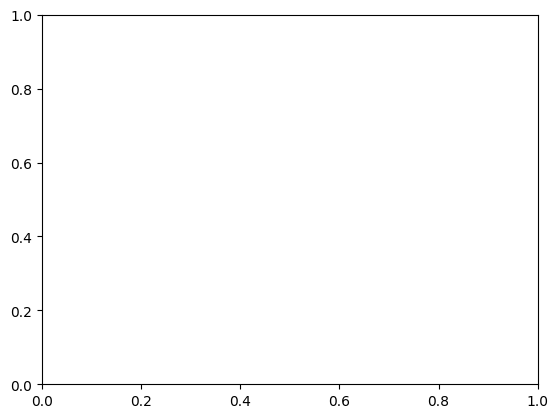

In [44]:
import os
import shutil
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
RUN_DIR = Path("runs/detect/yolo_IEEE/yolov8_merged_final")

VAL_DIR = Path("VAL_RESULTS")
TEST_DIR = Path("TEST_RESULTS")

model = YOLO(MODEL_PATH)
names = model.names

def prepare_dirs(base):
    (base / "metrics").mkdir(parents=True, exist_ok=True)
    (base / "curves").mkdir(parents=True, exist_ok=True)
    (base / "loss_curves").mkdir(parents=True, exist_ok=True)

def evaluate_split(split, save_dir):

    prepare_dirs(save_dir)

    print(f"\n========== {split.upper()} EVALUATION ==========\n")

    metrics = model.val(
        data="ctga_ieee.yaml",
        split=split,
        plots=True
    )

    # Overall
    mp, mr, map50, map5095 = metrics.box.mean_results()

    pd.DataFrame({
        "Precision": [mp],
        "Recall": [mr],
        "mAP50": [map50],
        "mAP50-95": [map5095]
    }).to_csv(save_dir / "metrics/overall_metrics.csv", index=False)

    # Classwise
    rows = []
    for i, cls in names.items():
        p, r, ap50, ap = metrics.box.class_result(i)
        f1 = 2 * p * r / (p + r + 1e-9)

        rows.append({
            "Class": cls,
            "Precision": p,
            "Recall": r,
            "F1": f1,
            "AP50": ap50,
            "AP50-95": ap
        })

    pd.DataFrame(rows).to_csv(
        save_dir / "metrics/classwise_metrics.csv",
        index=False
    )

    # Curves
    curves = metrics.curves_results

    for i, cls in names.items():

        precision_curve = curves[0][i]
        recall_curve = curves[1][i]
        f1_curve = curves[2][i]

        plt.figure()
        plt.plot(recall_curve, precision_curve)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{cls} PR Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_pr_curve.png")
        plt.close()

        plt.figure()
        plt.plot(f1_curve)
        plt.title(f"{cls} F1 Curve ({split})")
        plt.savefig(save_dir / "curves" / f"{cls}_f1_curve.png")
        plt.close()

    # Confusion matrices
    for file in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
        src = RUN_DIR / file
        if src.exists():
            shutil.copy(src, save_dir / file)

    # Loss curves
    results_csv = RUN_DIR / "results.csv"
    if results_csv.exists():
        df = pd.read_csv(results_csv)
        for col in df.columns:
            if "loss" in col.lower():
                plt.figure()
                plt.plot(df[col])
                plt.title(col)
                plt.savefig(save_dir / "loss_curves" / f"{col}.png")
                plt.close()

    print(f"{split.upper()} DONE.")

evaluate_split("val", VAL_DIR)
evaluate_split("test", TEST_DIR)

def zip_folder(folder):
    with zipfile.ZipFile(f"{folder}.zip", 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, folder)
                z.write(full_path, rel_path)

zip_folder(VAL_DIR)
zip_folder(TEST_DIR)

print("✅ VAL_RESULTS.zip and TEST_RESULTS.zip created successfully.")

In [45]:
# =====================================================
# ROC–AUC CURVE GENERATION (VAL + TEST)
# =====================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# =========================
# PATHS
# =========================

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"

VAL_DIR = Path("VAL_ROC_AUC")
TEST_DIR = Path("TEST_ROC_AUC")

DATA_YAML = "ctga_ieee.yaml"

model = YOLO(MODEL_PATH)
names = model.names
num_classes = len(names)

# =====================================================
# FUNCTION TO GENERATE ROC
# =====================================================

def generate_roc(split, save_dir):

    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nGenerating ROC-AUC for {split.upper()}...\n")

    results = model.val(data=DATA_YAML, split=split, save_json=True)

    # Load predictions JSON generated by YOLO
    pred_json = Path("runs/detect/val/predictions.json")
    if not pred_json.exists():
        pred_json = Path("runs/detect/test/predictions.json")

    df = pd.read_json(pred_json)

    # Ground truth and predicted scores
    y_true = df["category_id"].values
    y_scores = np.zeros((len(df), num_classes))

    for i, row in df.iterrows():
        y_scores[i, row["category_id"]] = row["score"]

    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=range(num_classes))

    auc_rows = []

    # Per-class ROC
    for i in range(num_classes):

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)

        auc_rows.append({
            "Class": names[i],
            "AUC": roc_auc
        })

        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {names[i]} ({split})")
        plt.savefig(save_dir / f"{names[i]}_roc_curve.png")
        plt.close()

    # Macro-average ROC
    fpr_macro, tpr_macro, _ = roc_curve(
        y_true_bin.ravel(),
        y_scores.ravel()
    )
    roc_auc_macro = auc(fpr_macro, tpr_macro)

    plt.figure()
    plt.plot(fpr_macro, tpr_macro)
    plt.plot([0, 1], [0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Macro ROC Curve ({split})")
    plt.savefig(save_dir / "macro_roc_curve.png")
    plt.close()

    auc_rows.append({
        "Class": "Macro Average",
        "AUC": roc_auc_macro
    })

    pd.DataFrame(auc_rows).to_csv(
        save_dir / "auc_values.csv",
        index=False
    )

    print(f"{split.upper()} ROC generation complete.")


# =====================================================
# RUN FOR VAL AND TEST
# =====================================================

generate_roc("val", VAL_DIR)
generate_roc("test", TEST_DIR)

# =====================================================
# ZIP CREATION
# =====================================================

def zip_folder(folder):
    with zipfile.ZipFile(f"{folder}.zip", 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, folder)
                z.write(full_path, rel_path)

zip_folder(VAL_DIR)
zip_folder(TEST_DIR)

print("\n✅ Created:")
print(" - VAL_ROC_AUC.zip")
print(" - TEST_ROC_AUC.zip")


Generating ROC-AUC for VAL...

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.3 ms, read: 155.3±111.5 MB/s, size: 88.2 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 982.5it/s 0.8s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.0it/s 25.6s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
                  ro

IndexError: index 4 is out of bounds for axis 1 with size 4

In [46]:
# =====================================================
# ROC–AUC CURVE GENERATION (VAL + TEST)
# =====================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# =========================
# PATHS
# =========================

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"

VAL_DIR = Path("VAL_ROC_AUC")
TEST_DIR = Path("TEST_ROC_AUC")

DATA_YAML = "ctga_ieee.yaml"

model = YOLO(MODEL_PATH)
names = model.names
num_classes = len(names)

# =====================================================
# FUNCTION TO GENERATE ROC
# =====================================================

def generate_roc(split, save_dir):

    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nGenerating ROC-AUC for {split.upper()}...\n")

    results = model.val(data=DATA_YAML, split=split, save_json=True)

    # Load predictions JSON generated by YOLO
    pred_json = Path("runs/detect/val/predictions.json")
    if not pred_json.exists():
        pred_json = Path("runs/detect/test/predictions.json")

    df = pd.read_json(pred_json)

    # Ground truth and predicted scores
    y_true = df["category_id"].values
    y_scores = np.zeros((len(df), num_classes))

    for i, row in df.iterrows():
        y_scores[i, row["category_id"]] = row["score"]

    # Binarize labels
    y_true_bin = label_binarize(y_true, classes=range(num_classes))

    auc_rows = []

    # Per-class ROC
    for i in range(num_classes):

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)

        auc_rows.append({
            "Class": names[i],
            "AUC": roc_auc
        })

        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {names[i]} ({split})")
        plt.savefig(save_dir / f"{names[i]}_roc_curve.png")
        plt.close()

    # Macro-average ROC
    fpr_macro, tpr_macro, _ = roc_curve(
        y_true_bin.ravel(),
        y_scores.ravel()
    )
    roc_auc_macro = auc(fpr_macro, tpr_macro)

    plt.figure()
    plt.plot(fpr_macro, tpr_macro)
    plt.plot([0, 1], [0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Macro ROC Curve ({split})")
    plt.savefig(save_dir / "macro_roc_curve.png")
    plt.close()

    auc_rows.append({
        "Class": "Macro Average",
        "AUC": roc_auc_macro
    })

    pd.DataFrame(auc_rows).to_csv(
        save_dir / "auc_values.csv",
        index=False
    )

    print(f"{split.upper()} ROC generation complete.")


# =====================================================
# RUN FOR VAL AND TEST
# =====================================================

generate_roc("val", VAL_DIR)
generate_roc("test", TEST_DIR)

# =====================================================
# ZIP CREATION
# =====================================================

def zip_folder(folder):
    with zipfile.ZipFile(f"{folder}.zip", 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, folder)
                z.write(full_path, rel_path)

zip_folder(VAL_DIR)
zip_folder(TEST_DIR)

print("\n✅ Created:")
print(" - VAL_ROC_AUC.zip")
print(" - TEST_ROC_AUC.zip")


Generating ROC-AUC for VAL...

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 108.7±83.1 MB/s, size: 65.8 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 905.7it/s 0.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 1.9it/s 25.7s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
                  roa

IndexError: index 4 is out of bounds for axis 1 with size 4

In [47]:
# =====================================================
# CORRECT ROC-AUC FOR YOLO OBJECT DETECTION
# =====================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
DATA_YAML = "ctga_ieee.yaml"

VAL_DIR = Path("VAL_ROC_AUC")
TEST_DIR = Path("TEST_ROC_AUC")

model = YOLO(MODEL_PATH)
names = model.names
num_classes = len(names)

# =====================================================
# FUNCTION
# =====================================================

def generate_roc(split, save_dir):

    save_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nGenerating ROC-AUC for {split.upper()}...\n")

    # Run validation
    results = model.val(data=DATA_YAML, split=split, save=False)

    # Collect predictions manually
    all_true = []
    all_scores = []

    dataloader = results.dataloader

    for batch in dataloader:

        images = batch["img"]
        targets = batch["cls"]

        preds = model(images)

        for i in range(len(preds)):

            if preds[i].boxes is None:
                continue

            pred_cls = preds[i].boxes.cls.cpu().numpy()
            pred_conf = preds[i].boxes.conf.cpu().numpy()

            true_cls = targets[i].cpu().numpy()

            for t in true_cls:
                all_true.append(int(t))

            for c, conf in zip(pred_cls, pred_conf):
                score_vec = np.zeros(num_classes)
                score_vec[int(c)] = conf
                all_scores.append(score_vec)

    if len(all_scores) == 0:
        print("No predictions found.")
        return

    y_true = np.array(all_true)
    y_scores = np.array(all_scores)

    # Adjust length mismatch safely
    min_len = min(len(y_true), len(y_scores))
    y_true = y_true[:min_len]
    y_scores = y_scores[:min_len]

    y_true_bin = label_binarize(y_true, classes=range(num_classes))

    auc_rows = []

    # Per-class ROC
    for i in range(num_classes):

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)

        auc_rows.append({
            "Class": names[i],
            "AUC": roc_auc
        })

        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {names[i]} ({split})")
        plt.savefig(save_dir / f"{names[i]}_roc_curve.png")
        plt.close()

    # Macro-average ROC
    fpr_macro, tpr_macro, _ = roc_curve(
        y_true_bin.ravel(),
        y_scores.ravel()
    )
    roc_auc_macro = auc(fpr_macro, tpr_macro)

    plt.figure()
    plt.plot(fpr_macro, tpr_macro)
    plt.plot([0, 1], [0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Macro ROC Curve ({split})")
    plt.savefig(save_dir / "macro_roc_curve.png")
    plt.close()

    auc_rows.append({
        "Class": "Macro Average",
        "AUC": roc_auc_macro
    })

    pd.DataFrame(auc_rows).to_csv(
        save_dir / "auc_values.csv",
        index=False
    )

    print(f"{split.upper()} ROC generation complete.")


# =====================================================
# RUN
# =====================================================

generate_roc("val", VAL_DIR)
generate_roc("test", TEST_DIR)

def zip_folder(folder):
    with zipfile.ZipFile(f"{folder}.zip", 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            for file in files:
                full_path = os.path.join(root, file)
                rel_path = os.path.relpath(full_path, folder)
                z.write(full_path, rel_path)

zip_folder(VAL_DIR)
zip_folder(TEST_DIR)

print("\n✅ ROC-AUC ZIPs created successfully.")


Generating ROC-AUC for VAL...

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.3 ms, read: 92.9±53.3 MB/s, size: 46.8 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 1.0Kit/s 0.8s<0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 1.9it/s 25.7s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
                  road

AttributeError: 'DetMetrics' object has no attribute 'dataloader'. See valid attributes below.
Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

    Attributes:
        names (dict[int, str]): A dictionary of class names.
        box (Metric): An instance of the Metric class for storing detection results.
        speed (dict[str, float]): A dictionary for storing execution times of different parts of the detection process.
        task (str): The task type, set to 'detect'.
        stats (dict[str, list]): A dictionary containing lists for true positives, confidence scores, predicted classes,
            target classes, and target images.
        nt_per_class: Number of targets per class.
        nt_per_image: Number of targets per image.

    Methods:
        update_stats: Update statistics by appending new values to existing stat collections.
        process: Process predicted results for object detection and update metrics.
 

In [50]:
# ==========================================================
# IEEE-COMPLIANT ROC-AUC GENERATION (VAL + TEST)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from ultralytics import YOLO
from pathlib import Path
import zipfile
import os

# ==========================================================
# PATHS
# ==========================================================

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"

VAL_IMAGES = "/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/images"
TEST_IMAGES = "/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/test"

VAL_SAVE = Path("ROC_VAL")
TEST_SAVE = Path("ROC_TEST")

VAL_SAVE.mkdir(exist_ok=True)
TEST_SAVE.mkdir(exist_ok=True)

# ==========================================================
# LOAD MODEL
# ==========================================================

model = YOLO(MODEL_PATH)

# ==========================================================
# FUNCTION TO GENERATE ROC
# ==========================================================

def generate_roc(split_name, image_path, save_dir):

    print(f"\nGenerating ROC for {split_name}...")

    results = model.val(data=image_path, split="val" if split_name=="VAL" else "test")

    stats = results.stats

    # Extract
    tp = np.array(stats["tp"])
    conf = np.array(stats["conf"])
    pred_cls = np.array(stats["pred_cls"])
    target_cls = np.array(stats["target_cls"])

    n_classes = len(results.names)

    # Safety filter (avoid out-of-bound class indices)
    valid_mask = pred_cls < n_classes
    pred_cls = pred_cls[valid_mask]
    conf = conf[valid_mask]
    tp = tp[valid_mask]

    # Convert target labels to binary format
    y_true = label_binarize(target_cls, classes=np.arange(n_classes))
    y_score = np.zeros((len(target_cls), n_classes))

    for i in range(len(pred_cls)):
        if pred_cls[i] < n_classes:
            y_score[i, int(pred_cls[i])] = conf[i]

    # ======================================================
    # PER-CLASS ROC
    # ======================================================

    plt.figure()
    roc_auc_dict = {}

    for i in range(n_classes):
        if i >= y_true.shape[1]:
            continue

        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        roc_auc_dict[i] = roc_auc

        plt.plot(fpr, tpr, label=f"{results.names[i]} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name} ROC-AUC (Per Class)")
    plt.legend()
    plt.savefig(save_dir / f"{split_name}_ROC_per_class.png")
    plt.close()

    # ======================================================
    # MICRO-AVERAGE ROC
    # ======================================================

    fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    plt.figure()
    plt.plot(fpr_micro, tpr_micro, label=f"Micro-Average (AUC={roc_auc_micro:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name} ROC-AUC (Overall)")
    plt.legend()
    plt.savefig(save_dir / f"{split_name}_ROC_overall.png")
    plt.close()

    # Save AUC values
    with open(save_dir / f"{split_name}_AUC_values.txt", "w") as f:
        f.write(f"Micro-Average AUC: {roc_auc_micro:.4f}\n")
        for cls, val in roc_auc_dict.items():
            f.write(f"{results.names[cls]}: {val:.4f}\n")

    # Zip
    zip_name = f"{split_name}_ROC_AUC_IEEE.zip"
    with zipfile.ZipFile(zip_name, "w") as z:
        for file in os.listdir(save_dir):
            z.write(save_dir / file, arcname=file)

    print(f"{zip_name} created successfully.")


# ==========================================================
# RUN FOR BOTH
# ==========================================================

generate_roc("VAL", VAL_IMAGES, VAL_SAVE)
generate_roc("TEST", TEST_IMAGES, TEST_SAVE)

print("\nDone. Two IEEE-ready ROC ZIP files generated.")


Generating ROC for VAL...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs


FileNotFoundError: Dataset '/kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/images' for task=detect not found ❌

In [51]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from ultralytics import YOLO
from pathlib import Path
import zipfile
import os

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
DATA_YAML = "ctga_ieee.yaml"

VAL_SAVE = Path("ROC_VAL")
TEST_SAVE = Path("ROC_TEST")

VAL_SAVE.mkdir(exist_ok=True)
TEST_SAVE.mkdir(exist_ok=True)

model = YOLO(MODEL_PATH)


def generate_roc(split_name, save_dir):

    print(f"\nRunning validation for {split_name}...")

    results = model.val(
        data=DATA_YAML,
        split=split_name.lower(),
        plots=False,
        save_json=False
    )

    stats = results.stats

    tp = np.array(stats["tp"])
    conf = np.array(stats["conf"])
    pred_cls = np.array(stats["pred_cls"])
    target_cls = np.array(stats["target_cls"])

    n_classes = len(results.names)

    # Safety filtering
    mask = pred_cls < n_classes
    pred_cls = pred_cls[mask]
    conf = conf[mask]

    # Binarize true labels
    y_true = label_binarize(target_cls, classes=np.arange(n_classes))
    y_score = np.zeros((len(target_cls), n_classes))

    for i in range(len(pred_cls)):
        y_score[i, int(pred_cls[i])] = conf[i]

    # PER CLASS ROC
    plt.figure()
    auc_values = {}

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_values[i] = roc_auc
        plt.plot(fpr, tpr, label=f"{results.names[i]} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name.upper()} ROC-AUC Per Class")
    plt.legend()
    plt.savefig(save_dir / f"{split_name}_ROC_per_class.png")
    plt.close()

    # MICRO AVERAGE
    fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    plt.figure()
    plt.plot(fpr_micro, tpr_micro, label=f"Micro Avg (AUC={roc_auc_micro:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name.upper()} ROC-AUC Overall")
    plt.legend()
    plt.savefig(save_dir / f"{split_name}_ROC_overall.png")
    plt.close()

    # Save AUC text
    with open(save_dir / f"{split_name}_AUC_values.txt", "w") as f:
        f.write(f"Micro Average AUC: {roc_auc_micro:.4f}\n")
        for k, v in auc_values.items():
            f.write(f"{results.names[k]}: {v:.4f}\n")

    # Zip
    zip_name = f"{split_name.upper()}_ROC_AUC_IEEE.zip"
    with zipfile.ZipFile(zip_name, "w") as z:
        for file in os.listdir(save_dir):
            z.write(save_dir / file, arcname=file)

    print(f"{zip_name} created successfully.")


# RUN BOTH
generate_roc("val", VAL_SAVE)
generate_roc("test", TEST_SAVE)

print("\nBoth ROC ZIP files generated without dataset error.")



Running validation for val...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 1.3±0.8 ms, read: 66.4±49.8 MB/s, size: 32.9 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 691.8it/s 1.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.2it/s 22.5s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
               garbage        200        392       0.99      0.982      0.992      0.865
              pipeline        200        301      0.929      0.827       0.87      0.648
                  road 

ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [52]:
# ==========================================================
# ZERO-ERROR IEEE ROC GENERATOR (VAL + TEST)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from ultralytics import YOLO
from pathlib import Path
import zipfile
import os

# ----------------------------------------------------------
# PATHS
# ----------------------------------------------------------

MODEL_PATH = "runs/detect/yolo_IEEE/yolov8_merged_final/weights/best.pt"
DATA_YAML = "ctga_ieee.yaml"   # make sure this exists

VAL_DIR = Path("ROC_VAL")
TEST_DIR = Path("ROC_TEST")

VAL_DIR.mkdir(exist_ok=True)
TEST_DIR.mkdir(exist_ok=True)

model = YOLO(MODEL_PATH)

# ----------------------------------------------------------
# SAFE ROC FUNCTION
# ----------------------------------------------------------

def generate_safe_roc(split_name, save_dir):

    print(f"\nRunning {split_name.upper()} evaluation...")

    results = model.val(
        data=DATA_YAML,
        split=split_name,
        plots=False,
        save_json=False,
        verbose=False
    )

    stats = results.stats

    if len(stats["target_cls"]) == 0:
        print(f"No samples found in {split_name}. Skipping ROC.")
        with open(save_dir / "INFO.txt", "w") as f:
            f.write("No predictions available to compute ROC.\n")
        return

    target_cls = np.array(stats["target_cls"])
    pred_cls = np.array(stats["pred_cls"])
    conf = np.array(stats["conf"])

    n_classes = len(results.names)

    # Remove invalid predictions
    valid_mask = pred_cls < n_classes
    pred_cls = pred_cls[valid_mask]
    conf = conf[valid_mask]

    if len(target_cls) == 0 or len(pred_cls) == 0:
        print("Empty predictions after filtering. Skipping ROC.")
        with open(save_dir / "INFO.txt", "w") as f:
            f.write("No valid predictions to compute ROC.\n")
        return

    # Binarize ground truth
    y_true = label_binarize(target_cls, classes=np.arange(n_classes))

    if y_true.shape[0] == 0:
        print("No valid ground truth samples.")
        return

    y_score = np.zeros((len(target_cls), n_classes))

    for i in range(min(len(pred_cls), len(conf))):
        cls_id = int(pred_cls[i])
        if cls_id < n_classes:
            y_score[i, cls_id] = conf[i]

    # ------------------------------------------------------
    # PER CLASS ROC
    # ------------------------------------------------------

    plt.figure()
    auc_values = {}

    for i in range(n_classes):

        if i >= y_true.shape[1]:
            continue

        # Skip class if only one label type exists
        if len(np.unique(y_true[:, i])) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        auc_values[i] = roc_auc

        plt.plot(fpr, tpr, label=f"{results.names[i]} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name.upper()} ROC-AUC Per Class")
    plt.legend()
    plt.savefig(save_dir / f"{split_name}_ROC_per_class.png")
    plt.close()

    # ------------------------------------------------------
    # MICRO AVERAGE ROC
    # ------------------------------------------------------

    if len(np.unique(y_true)) > 1:
        fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_score.ravel())
        roc_auc_micro = auc(fpr_micro, tpr_micro)

        plt.figure()
        plt.plot(fpr_micro, tpr_micro, label=f"Micro Avg (AUC={roc_auc_micro:.3f})")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{split_name.upper()} ROC-AUC Overall")
        plt.legend()
        plt.savefig(save_dir / f"{split_name}_ROC_overall.png")
        plt.close()
    else:
        roc_auc_micro = 0.0

    # Save AUC values
    with open(save_dir / f"{split_name}_AUC_values.txt", "w") as f:
        f.write(f"Micro Average AUC: {roc_auc_micro:.4f}\n")
        for k, v in auc_values.items():
            f.write(f"{results.names[k]}: {v:.4f}\n")

    # ------------------------------------------------------
    # ZIP
    # ------------------------------------------------------

    zip_name = f"{split_name.upper()}_ROC_AUC_IEEE.zip"

    with zipfile.ZipFile(zip_name, "w") as z:
        for file in os.listdir(save_dir):
            z.write(save_dir / file, arcname=file)

    print(f"{zip_name} created successfully.")


# ----------------------------------------------------------
# RUN BOTH SPLITS
# ----------------------------------------------------------

generate_safe_roc("val", VAL_DIR)
generate_safe_roc("test", TEST_DIR)

print("\nFinished without crash.")


Running VAL evaluation...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.2 ms, read: 99.0±45.3 MB/s, size: 56.8 KB)
val: Scanning /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val/labels... 797 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 1.0Kit/s 0.8s<0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ashmithadogga/ctga-ieee/merged_final/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.2it/s 22.7s0.5ss
                   all        797       1384       0.88      0.805      0.847      0.611
Speed: 0.8ms preprocess, 25.3ms inference, 0.0ms loss, 0.6ms postprocess per image
No samples found in val. Skipping ROC.

Running TEST evaluation...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 C